In [1]:
import torch
import cv2
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import OxfordIIITPet
import albumentations as A
from albumentations.pytorch import ToTensorV2

Data Augmentation

In [2]:
train_transform=A.Compose([
    A.Resize(width=256,height=256),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20,p=0.5),
    A.Normalize(),
    ToTensorV2()
])
test_transform=A.Compose([
    A.Resize(width=256,height=256),
    A.Normalize(),
    ToTensorV2()
])

Preparing the custom dataset

In [22]:
class PetDataset(Dataset):
  def __init__(self,root=".",transform=None,split="trainval"):
    self.dataset=OxfordIIITPet(
        root=root,
        download=True,
        target_types='segmentation',
        split=split
    )
    self.transform=transform
  def __len__(self):
    return len(self.dataset)

  def __getitem__(self,idx):
    image,mask=self.dataset[idx]
    image=np.array(image)
    mask=np.array(mask)

    #binary segmentation
    mask=(mask==1).astype(np.float32)
    if self.transform:
      augmented=self.transform(image=image,mask=mask)
      image=augmented["image"]
      mask=augmented["mask"]
    mask=mask.unsqueeze(0)
    return image,mask

In [23]:
train_dataset=PetDataset(split="trainval",transform=train_transform)
val_dataset=PetDataset(split="test",transform=test_transform)

train_loader=DataLoader(train_dataset,batch_size=8,shuffle=True,pin_memory=True,num_workers=2)
val_loader=DataLoader(val_dataset,batch_size=8,shuffle=False,pin_memory=True,num_workers=2)

## Transfer Learning U-Net

In [24]:
pip install segmentation_models_pytorch

In [25]:
import segmentation_models_pytorch as smp

In [26]:
model=smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

Losses (Dice loss + BCE loss)

In [27]:
# from smp.losses import DiceLoss
# we can import it as well

In [28]:
import torch.nn as nn

In [29]:
class DiceLoss(nn.Module):
  def __init__(self,smooth=1e-6):
    super().__init__()
    self.smooth=smooth

  def forward(self,preds,targets):
    preds=torch.sigmoid(preds)
    preds=preds.flatten()
    targets=targets.flatten()
    intersection=(preds*targets).sum()
    dice=(2.0*intersection+self.smooth)/(preds.sum()+targets.sum()+self.smooth)
    return 1-dice

In [30]:
bce=nn.BCEWithLogitsLoss()
dice=DiceLoss()

In [31]:
def loss_fn(preds,targets):
  return bce(preds,targets)+dice(preds,targets)

Intersection over Union / Jaccard Index

In [38]:
def iou_score(preds,targets,smooth=1e-6):
  preds=torch.sigmoid(preds)
  preds=(preds>0.5).float()
  preds=preds.flatten()
  targets=targets.flatten()
  intersection=(preds*targets).sum()
  union=(preds+targets).sum()-intersection
  iou=(intersection+smooth)/(union+smooth)
  return iou

Model Building

In [39]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=model.to(device)

In [40]:
optimizer=torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [41]:
def train(model,loader,optimizer,loss_fn,device):
  model.train()
  total_loss=0
  total_iou=0
  for images,masks in loader:
    images=images.to(device)
    masks=masks.to(device)
    optimizer.zero_grad()
    output=model(images)
    loss=loss_fn(output,masks)
    loss.backward()
    optimizer.step()

    total_loss+=loss.item()
    total_iou+=iou_score(output,masks)

  avg_loss=total_loss/len(loader)
  avg_iou=total_iou/len(loader)
  return avg_loss,avg_iou

In [44]:
def val(model,loss_fn,device,loader):
  model.eval()
  total_loss=0
  total_iou=0

  with torch.no_grad():
    for images,masks in loader:
      images,masks=images.to(device),masks.to(device)
      output=model(images)
      loss=loss_fn(output,masks)
      total_loss+=loss.item()
      total_iou+=iou_score(output,masks)

  avg_loss=total_loss/len(loader)
  avg_iou=total_iou/len(loader)
  return avg_loss,avg_iou

Train/Val Loop

In [45]:
EPOCHS=5
for epoch in range(EPOCHS):
  train_loss,train_iou=train( model=model, loader=train_loader, optimizer=optimizer, loss_fn=loss_fn, device=device )
  val_loss,val_iou=val( model=model, loss_fn=loss_fn, device=device, loader=val_loader )
  print(f"Epoch [{epoch+1}/{EPOCHS}]")
  print(f"Train Loss: {train_loss:.4f} | "f"Train IoU: {train_iou:.4f}")
  print(f"Val Loss: {val_loss:.4f} | "f"Val IoU: {val_iou:.4f}")

Epoch [1/5]
Train Loss: 0.2862 | Train IoU: 0.8534
Val Loss: 0.2488 | Val IoU: 0.8567
Epoch [2/5]
Train Loss: 0.2284 | Train IoU: 0.8660
Val Loss: 0.2168 | Val IoU: 0.8702
Epoch [3/5]
Train Loss: 0.1994 | Train IoU: 0.8769
Val Loss: 0.2216 | Val IoU: 0.8625
Epoch [4/5]
Train Loss: 0.1845 | Train IoU: 0.8825
Val Loss: 0.2128 | Val IoU: 0.8681
Epoch [5/5]
Train Loss: 0.1755 | Train IoU: 0.8855
Val Loss: 0.2473 | Val IoU: 0.8525


In [46]:
import matplotlib.pyplot as plt

In [47]:
def visualize_predictions(
    model,
    loader,
    device,
    num_images=5
):

    model.eval()

    with torch.no_grad():

        images, masks = next(iter(loader))

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        preds = torch.sigmoid(outputs)

        preds = (preds > 0.5).float()

        images = images.cpu()
        masks = masks.cpu()
        preds = preds.cpu()

        for i in range(num_images):

            image = images[i].permute(1, 2, 0).numpy()

            mask = masks[i].squeeze().numpy()

            pred = preds[i].squeeze().numpy()

            plt.figure(figsize=(12,4))

            # Original Image
            plt.subplot(1,3,1)
            plt.imshow(image)
            plt.title("Image")
            plt.axis("off")

            # Ground Truth
            plt.subplot(1,3,2)
            plt.imshow(mask, cmap="gray")
            plt.title("Ground Truth")
            plt.axis("off")

            # Prediction
            plt.subplot(1,3,3)
            plt.imshow(pred, cmap="gray")
            plt.title("Prediction")
            plt.axis("off")

            plt.show()

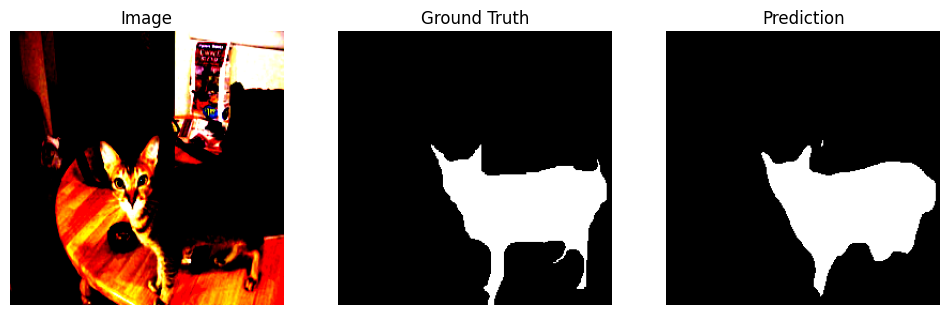

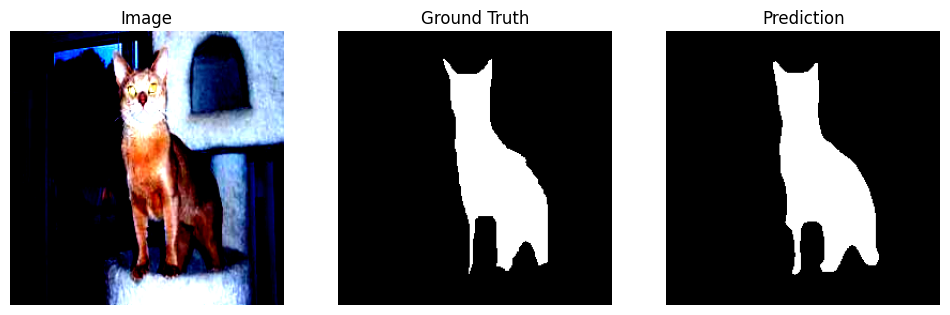

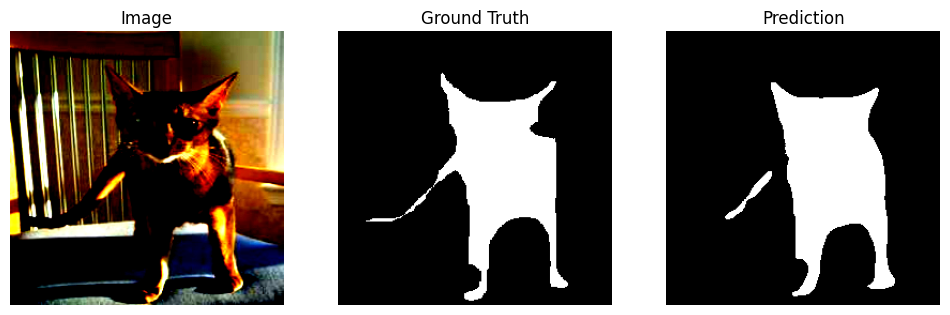

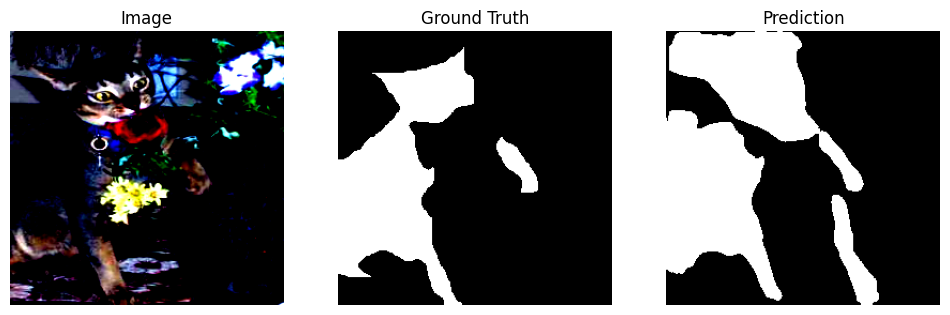

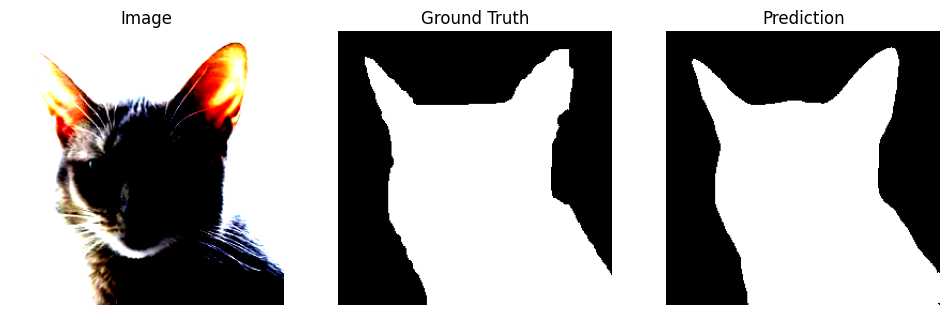

In [48]:
visualize_predictions(
    model,
    val_loader,
    device
)

In [49]:
torch.save(
    model.state_dict(),
    "unet_resnet34_segmentation.pth"
)